In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matlab.engine 

In [3]:
eng = matlab.engine.start_matlab()
eng.eval("load('shared.mat')", nargout=0)   # or run your script to create y_accum
y_accum = np.array(eng.workspace['y_accum'])
Xgrid   = np.array(eng.workspace['Xgrid'])
Ygrid   = np.array(eng.workspace['Ygrid'])
Zgrid   = np.array(eng.workspace['Zgrid'])

In [15]:
%pip install -U scikit-image scipy


  Using cached scipy-1.16.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.8 MB 16.9 MB/s eta 0:00:01
   ---------------- ----------------------- 5.2/12.8 MB 17.7 MB/s eta 0:00:01
   ---------------------------- ----------- 9.2/12.8 MB 17.3 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.8 MB 17.9 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 16.7 MB/s  0:00:00
Using cached scipy-1.16.1-cp311-cp311-win_amd64.whl (38.6 MB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 37.7 MB/s  0:00:00

   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ------ ------------------

In [19]:
# %pip install scikit-image scipy   # run once if needed

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter

EPS = 1e-12

def _axis1d(axis, n):
    if axis is None:
        return np.arange(n)
    a = np.asarray(axis).ravel()
    if a.size != n:
        raise ValueError(f"axis length {a.size} != {n}")
    return a

def plot_25_isosurfaces(vol_stack, Y=None, X=None, Z=None,
                        iso_db=None, perc=98.5,
                        smooth_sigma=1.0, step=1, alpha=0.85):
    """
    vol_stack : (Ny, Nx, Nz, N) complex or real
    Axes in plot follow your convention: plot X <- Y, plot Y <- X, plot Z <- Z.

    iso_db    : isosurface level in dB (global 0 dB ref). If None, per-scan percentile 'perc' is used.
    perc      : percentile (e.g., 98.5) if iso_db is None (lower -> more surface).
    smooth_sigma : Gaussian sigma (voxels) before marching cubes to de-block.
    step      : marching cubes step_size (1=most detail, 2=faster).
    alpha     : surface transparency.
    """
    Ny, Nx, Nz, N = vol_stack.shape
    Nplot = min(25, N)

    # Build 1-D coordinate axes (Y horizontal, X vertical, Z range)
    yi = _axis1d(Y, Ny); xi = _axis1d(X, Nx); zi = _axis1d(Z, Nz)
    dy = float(np.mean(np.diff(yi))) if Ny > 1 else 1.0
    dx = float(np.mean(np.diff(xi))) if Nx > 1 else 1.0
    dz = float(np.mean(np.diff(zi))) if Nz > 1 else 1.0
    ymin, xmin, zmin = float(yi.min()), float(xi.min()), float(zi.min())

    # Global reference so every panel shares 0 dB
    ref_mag = np.abs(vol_stack[..., :Nplot]).max() + EPS

    fig = plt.figure(figsize=(18, 18))
    for i in range(Nplot):
        vol = np.abs(vol_stack[..., i]).astype(np.float64)
        vol_db = 20.0 * np.log10(vol / ref_mag + EPS)

        if smooth_sigma and smooth_sigma > 0:
            vol_db = gaussian_filter(vol_db, smooth_sigma)

        level = float(np.percentile(vol_db, perc)) if iso_db is None else float(iso_db)

        # marching_cubes expects array axes order (0,1,2) -> here (y,x,z)
        try:
            verts, faces, _, _ = marching_cubes(vol_db, level=level,
                                                spacing=(dy, dx, dz), step_size=step)
        except Exception:
            # If level too high (no surface), skip
            ax = fig.add_subplot(5, 5, i+1, projection='3d')
            ax.set_title(f"{i+1} (no surface)"); ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
            continue

        # Convert to physical coords and to your plotting convention:
        # verts columns are (y, x, z). We plot X<-Y, Y<-X, Z<-Z.
        VX = ymin + verts[:, 0]   # plot X axis shows Y coords (horizontal)
        VY = xmin + verts[:, 1]   # plot Y axis shows X coords (vertical)
        VZ = zmin + verts[:, 2]   # plot Z axis shows Z (down-range)
        V  = np.c_[VX, VY, VZ]

        ax = fig.add_subplot(5, 5, i+1, projection='3d')
        mesh = Poly3DCollection(V[faces], alpha=alpha)
        mesh.set_edgecolor('none')
        ax.add_collection3d(mesh)

        # Common limits across panels
        ax.set_xlim(yi.min(), yi.max())   # plot X <- Y
        ax.set_ylim(xi.min(), xi.max())   # plot Y <- X
        ax.set_zlim(zi.min(), zi.max())   # plot Z <- Z

        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        ax.set_title(f"{i+1}")
        ax.set_xlabel("Y (horizontal)")
        ax.set_ylabel("X (vertical)")
        ax.set_zlabel("Z (down-range)")

    plt.tight_layout()
    plt.show()


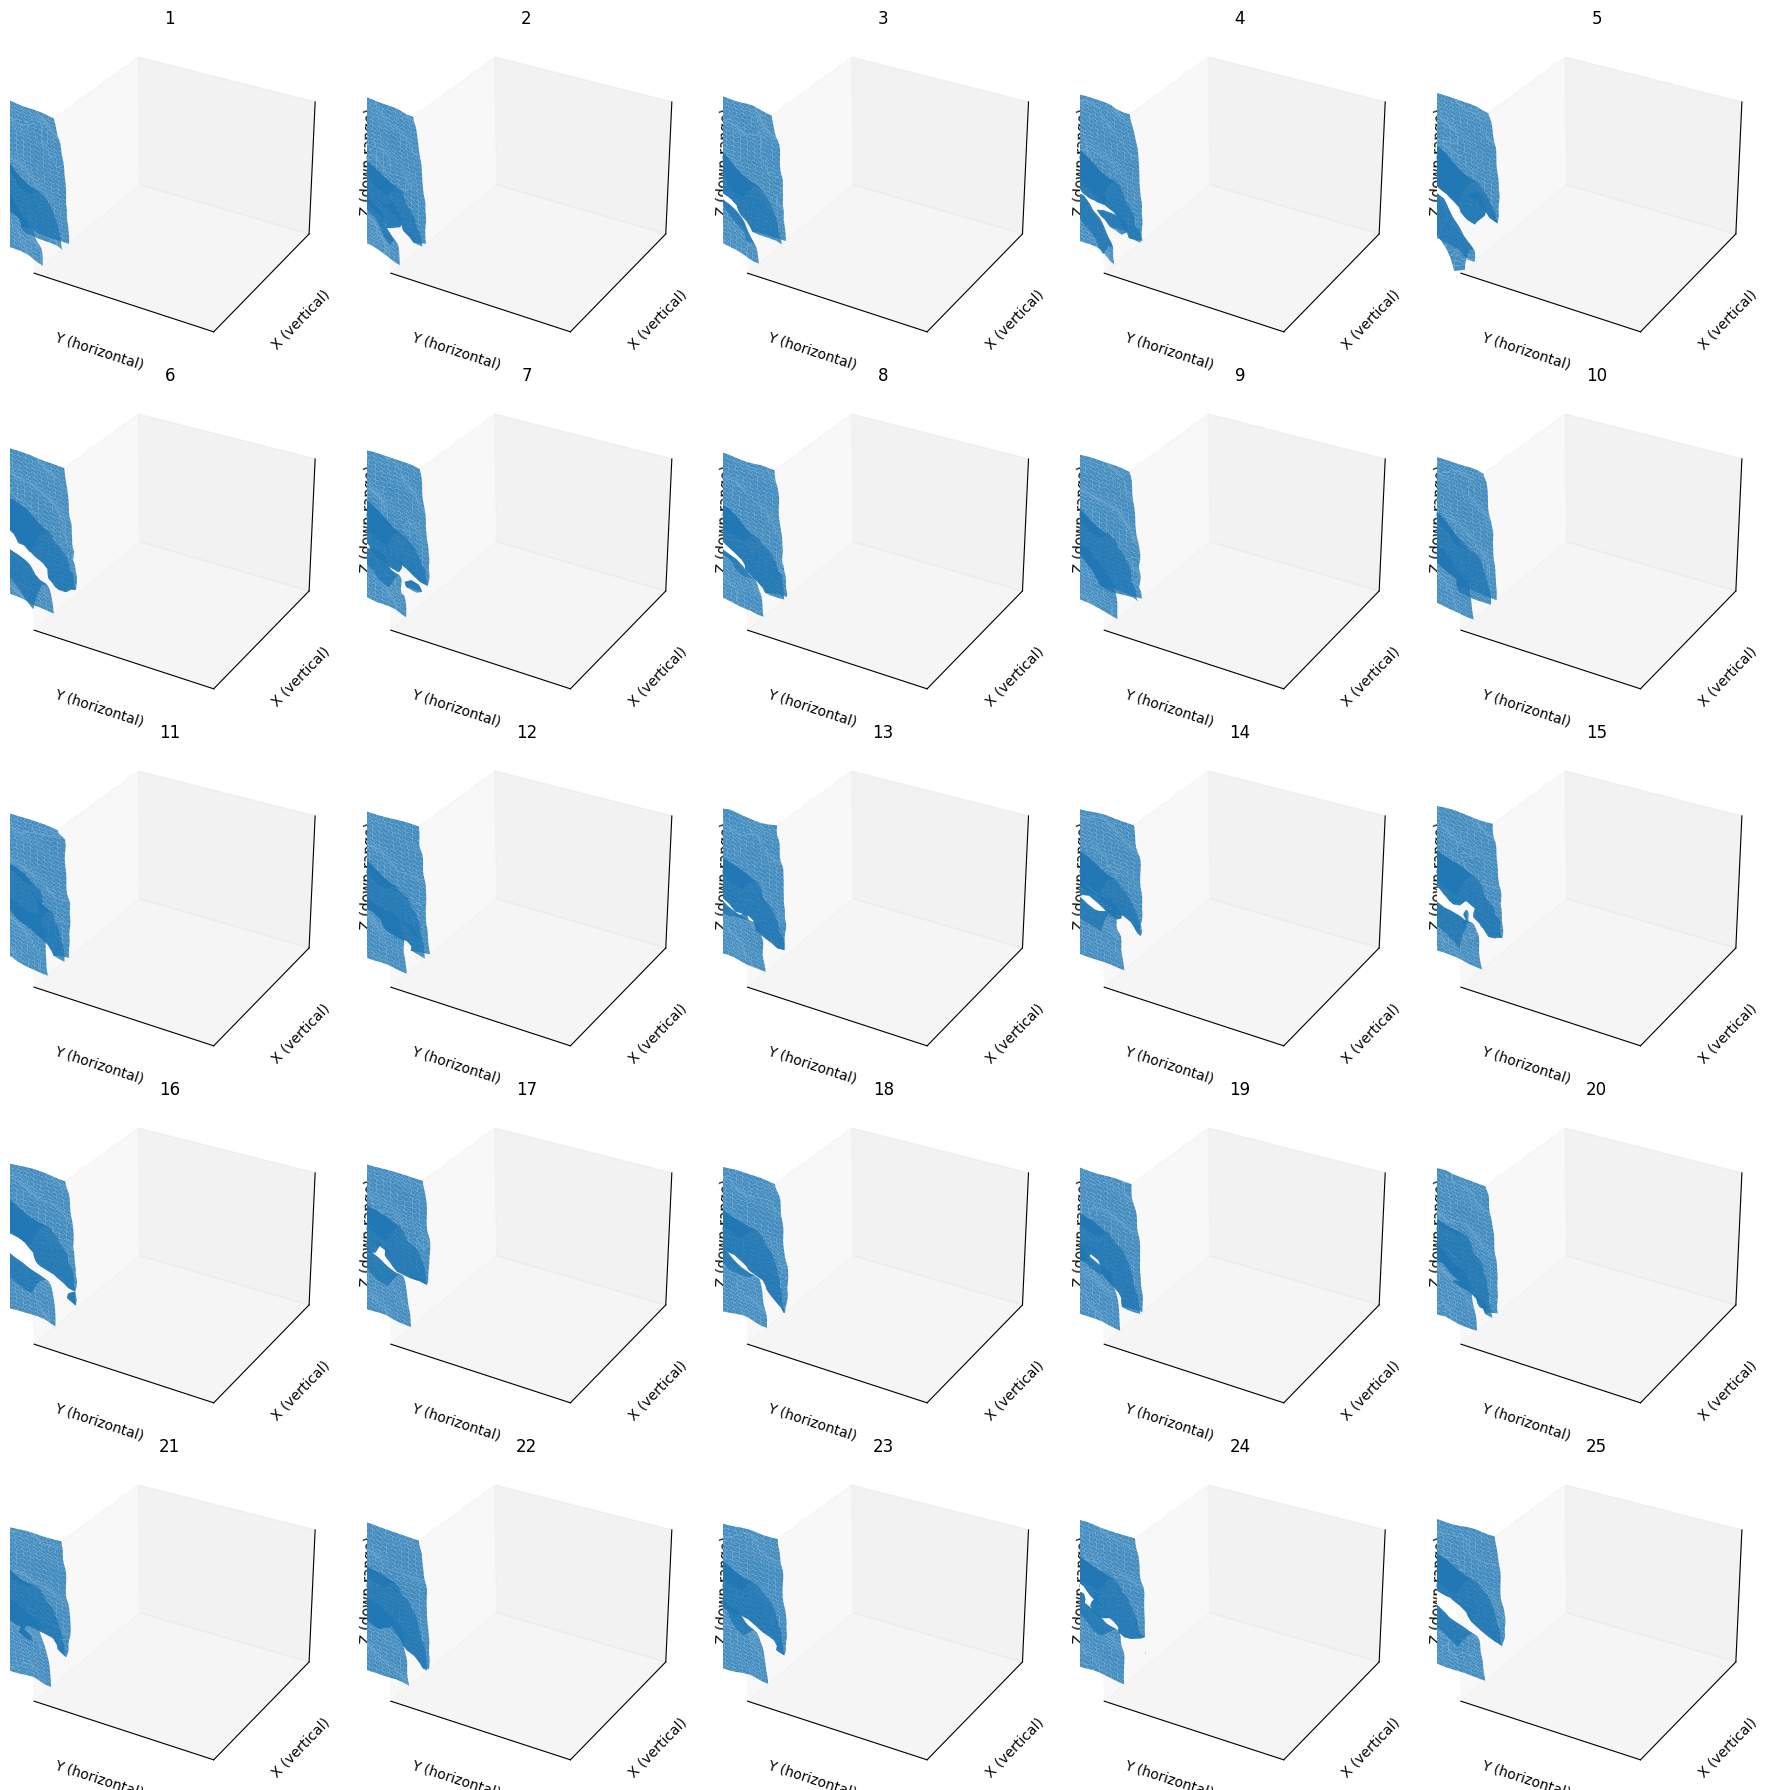

In [21]:
# Build 1-D axes from your meshgrids (if you have them)
Y = Ygrid[:,0,0] if Ygrid.ndim==3 else Ygrid
X = Xgrid[0,:,0] if Xgrid.ndim==3 else Xgrid
Z = Zgrid[0,0,:] if Zgrid.ndim==3 else Zgrid

# vol_stack must be (Ny, Nx, Nz, 25) complex
plot_25_isosurfaces(
    y_accum, Y=Y, X=X, Z=Z,
    iso_db=None,    # or set e.g. iso_db=-12 to use an absolute level
    perc=20.0,      # lower -> more surface; raise if too dense
    smooth_sigma=1, # 1–1.5 smooths blockiness well
    step=1,         # 1 = highest detail, 2 is faster/smoother
    alpha=0.85
)
